# 04 - Modeling Progression

**Goal:** Find the best non-fine-tuned classifier for the news source classification task and understand what it's learning.

**Central question:** How much of the predictive signal is topic-based (what Fox/NBC cover) vs. style-based (how they write)?

**Sections:**
1. Data loading and train/test split (temporal and stratified)
2. Stage 1 — Baseline TF-IDF + Logistic Regression (assignment benchmark)
3. Stage 2 — Improved TF-IDF (bigrams, more features)
4. Stage 3 — Sentence embeddings (MiniLM) with multiple classifiers
5. Stage 4 — Stylistic features only (XGBoost, SVC)
6. Stage 5 — Embedding + Stylistic Features (XGBoost, SVC)
7. Model comparison and error analysis

**Key result:** MiniLM + SVM achieves 75.5% (temporal), stylometric features alone reach 73.8%, fusion reaches ~76-77%. DistilBERT (notebook 05) achieves 82.4%.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import sys

sys.path.append('../scripts')
from rk_feature_engineering import run_full_style_feature_pipeline, FEATURE_COLS

plt.rcParams['figure.dpi'] = 120
FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'

/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Train/Test Split

We use a **temporal split**: sort all dated articles chronologically, use the earliest 80% for training and latest 20% for test.

**Rationale:** The graders' hidden test set will contain articles published after our collection date. A random split would leak future writing styles into training. Articles missing datetimes are assigned to training only (conservative choice).

We also compute a stratified split and report both — the gap measures temporal distribution shift.

In [2]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, format='mixed')
df = df.dropna(subset=['title']).copy()

print(f'Total articles: {len(df):,}')
print(f'Fox: {df["is_fox"].sum():,} | NBC: {(df["is_fox"]==0).sum():,}')
print(f'Missing datetimes: {df["datetime_posted"].isna().sum():,}')

Total articles: 3,801
Fox: 2,000 | NBC: 1,801
Missing datetimes: 90


In [3]:
# ── Temporal split ────────────────────────────────────────────────────────────
df_dated   = df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
df_undated = df[df['datetime_posted'].isna()]

split_idx = int(len(df_dated) * 0.8)
train_t = pd.concat([df_dated.iloc[:split_idx], df_undated], ignore_index=True)
test_t = df_dated.iloc[split_idx:].reset_index(drop=True)

print(f'\nTemporal split:')
print(f'\tTrain: {len(train_t):,} | Fox%: {train_t["is_fox"].mean():.2%}')
print(f'\tTest:  {len(test_t):,}  | Fox%: {test_t["is_fox"].mean():.2%}')
print(f'\tTest date range: {test_t["datetime_posted"].min().date()} → {test_t["datetime_posted"].max().date()}')

X_train_text = train_t['title'].tolist()
X_test_text = test_t['title'].tolist()
y_train = train_t['is_fox'].tolist()
y_test = test_t['is_fox'].tolist()


Temporal split:
	Train: 3,058 | Fox%: 52.22%
	Test:  743  | Fox%: 54.24%
	Test date range: 2024-09-27 → 2026-04-07


In [4]:
# ── Stratified split ──────────────────────────────────────────────────────────
train_s, test_s = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fox'])
train_s = train_s.reset_index(drop=True)
test_s  = test_s.reset_index(drop=True)

print(f'\nStratified split:')
print(f'\tTrain: {len(train_s):,} | Fox%: {train_s["is_fox"].mean():.2%}')
print(f'\tTest:  {len(test_s):,}  | Fox%: {test_s["is_fox"].mean():.2%}')

X_train_text_s = train_s['title'].tolist()
X_test_text_s  = test_s['title'].tolist()
y_train_s      = train_s['is_fox'].tolist()
y_test_s       = test_s['is_fox'].tolist()


Stratified split:
	Train: 3,040 | Fox%: 52.63%
	Test:  761  | Fox%: 52.56%


## 2. Stage 1: Baseline TF-IDF + Logistic Regression

Reproducing the assignment baseline exactly (100 TF-IDF features, LR) as a local benchmark, then improving it.

In [5]:
# ── Temporal split ──────────────────────────────────────────────────────────

# Assignment baseline — exact settings from spec
vec_base = TfidfVectorizer(stop_words='english', max_features=100)
lr_base  = LogisticRegression(max_iter=100, random_state=42)
lr_base.fit(vec_base.fit_transform(X_train_text), y_train)
acc_base = accuracy_score(y_test, lr_base.predict(vec_base.transform(X_test_text)))
print(f'Assignment baseline (temporal): {acc_base:.4f}')

# Improved TF-IDF: 5000 features, bigrams, sublinear TF
vec_imp  = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), sublinear_tf=True)
lr_imp   = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_imp.fit(vec_imp.fit_transform(X_train_text), y_train)
acc_imp  = accuracy_score(y_test, lr_imp.predict(vec_imp.transform(X_test_text)))
print(f'Improved TF-IDF LR (temporal):  {acc_imp:.4f}')
print(classification_report(y_test, lr_imp.predict(vec_imp.transform(X_test_text)), target_names=['NBC', 'Fox']))

Assignment baseline (temporal): 0.6864
Improved TF-IDF LR (temporal):  0.7362
              precision    recall  f1-score   support

         NBC       0.72      0.69      0.70       340
         Fox       0.75      0.78      0.76       403

    accuracy                           0.74       743
   macro avg       0.73      0.73      0.73       743
weighted avg       0.74      0.74      0.74       743



In [6]:
# ── Stratified split ──────────────────────────────────────────────────────────

# Assignment baseline 
vec_base_s = TfidfVectorizer(stop_words='english', max_features=100)
lr_base_s  = LogisticRegression(max_iter=100, random_state=42)
lr_base_s.fit(vec_base_s.fit_transform(X_train_text_s), y_train_s)
acc_base_s = accuracy_score(y_test_s, lr_base_s.predict(vec_base_s.transform(X_test_text_s)))
print(f'Assignment baseline (stratified): {acc_base_s:.4f}')

# Improved TF-IDF: 5000 features, bigrams, sublinear TF
vec_imp_s  = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), sublinear_tf=True)
lr_imp_s   = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_imp_s.fit(vec_imp_s.fit_transform(X_train_text_s), y_train_s)
acc_imp_s  = accuracy_score(y_test_s, lr_imp_s.predict(vec_imp_s.transform(X_test_text_s)))
print(f'Improved TF-IDF LR (stratified): {acc_imp_s:.4f}')

Assignment baseline (stratified): 0.7096
Improved TF-IDF LR (stratified): 0.7950


## 3. Stage 2: Sentence Embeddings (MiniLM)

`all-MiniLM-L6-v2` produces 384-dimension dense vectors that capture semantic meaning beyond bag-of-words. We try three classifiers on top. **SVM with RBF kernel** performs best.

In [7]:
# ── Stratified split ──────────────────────────────────────────────────────────

# MiniLM embeddings + scaling for SVM/LR
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = embedder.encode(X_train_text, show_progress_bar=True)
X_test_emb = embedder.encode(X_test_text,  show_progress_bar=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

Batches: 100%|██████████| 24/24 [00:00<00:00, 46.93it/s]


In [8]:
# ── Temporal split ──────────────────────────────────────────────────────────

# Collect model performance in results_emb
results_emb = {}

for name, clf in [
    ('MiniLM + LR - Temporal',  LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ('MiniLM + RF - Temporal',  RandomForestClassifier(n_estimators=300, random_state=42)),
    ('MiniLM + SVM - Temporal', SVC(kernel='rbf', C=1.0, random_state=42)),
]:
    X_tr = X_train_emb if 'RF' in name else X_train_scaled
    X_te = X_test_emb  if 'RF' in name else X_test_scaled
    clf.fit(X_tr, y_train)
    acc = accuracy_score(y_test, clf.predict(X_te))
    results_emb[name] = acc
    print(f'{name}: {acc:.4f}')

MiniLM + LR - Temporal: 0.7120
MiniLM + RF - Temporal: 0.7133
MiniLM + SVM - Temporal: 0.7550


In [9]:
# ── Temporal split ──────────────────────────────────────────────────────────

# Test XGBoost with embeddings --> separate cell to avoid memory crash
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8, random_state=42,
                    eval_metric='logloss')
X_tr = X_train_emb
X_te = X_test_emb
clf.fit(X_tr, y_train)
acc_xgb = accuracy_score(y_test, clf.predict(X_te))
results_emb["MiniLM + XGB - Temporal"] = acc_xgb
print(f"MiniLM + XGB - Temporal: {acc_xgb:.4f}")

MiniLM + XGB - Temporal: 0.7295


In [10]:
# Display best model using MiniLM embeddings for temporal split
best_emb_name = max(results_emb, key = results_emb.get)
print(f'Best predictor using MiniLM embeddings (temporal): {best_emb_name} ({results_emb[best_emb_name]:.4f})')

Best predictor using MiniLM embeddings (temporal): MiniLM + SVM - Temporal (0.7550)


In [11]:
# ── Stratified split ─────────────────────────────────────

# MiniLM embeddings + scaling for SVM/LR (on stratified split)
X_train_emb_s = embedder.encode(X_train_text_s, show_progress_bar=True)
X_test_emb_s  = embedder.encode(X_test_text_s,  show_progress_bar=True)

scaler_s = StandardScaler()
X_train_scaled_s = scaler_s.fit_transform(X_train_emb_s)
X_test_scaled_s  = scaler_s.transform(X_test_emb_s)

Batches: 100%|██████████| 24/24 [00:00<00:00, 49.58it/s]


In [12]:
# ── Stratified split ─────────────────────────────────────

# Store results for stratified split in separate dictionary
results_emb_s = {}

for name, clf in [
    ('MiniLM + LR - Stratified',  LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ('MiniLM + RF - Stratified',  RandomForestClassifier(n_estimators=300, random_state=42)),
    ('MiniLM + SVM - Stratified', SVC(kernel='rbf', C=1.0, random_state=42)),
]:
    X_tr = X_train_emb_s if 'RF' in name else X_train_scaled_s
    X_te = X_test_emb_s  if 'RF' in name else X_test_scaled_s
    clf.fit(X_tr, y_train_s)
    acc = accuracy_score(y_test_s, clf.predict(X_te))
    results_emb_s[name] = acc
    print(f'{name} (stratified): {acc:.4f}')

MiniLM + LR - Stratified (stratified): 0.7582
MiniLM + RF - Stratified (stratified): 0.7359
MiniLM + SVM - Stratified (stratified): 0.8055


In [13]:
# ── Stratified split ─────────────────────────────────────

# Test XGBoost with embeddings --> separate cell to avoid memory crash (stratified split)
clf_s = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42,
                      eval_metric='logloss')
clf_s.fit(X_train_emb_s, y_train_s)
acc_xgb_s = accuracy_score(y_test_s, clf_s.predict(X_test_emb_s))
results_emb_s['MiniLM + XGB - Stratified'] = acc_xgb_s
print(f'MiniLM + XGB - Stratified: {acc_xgb_s:.4f}')

MiniLM + XGB - Stratified: 0.7806


In [14]:
# Display best model using MiniLM embeddings for stratified split
best_emb_name = max(results_emb_s, key = results_emb_s.get)
print(f'Best predictor using MiniLM embeddings (stratified): {best_emb_name} ({results_emb_s[best_emb_name]:.4f})')

Best predictor using MiniLM embeddings (stratified): MiniLM + SVM - Stratified (0.8055)


## 4. Stage 3: Stylistic Features Only

5 engineered features from the EDA (see `03_style_eda.ipynb`). This tests whether style alone — with *zero* topic information — is predictive. Uses precomputed features from `data/processed/style_features.csv`.

In [15]:
# Load precomputed stylistic feature data
feature_df = pd.read_csv('../data/processed/style_features.csv')
feature_df['datetime_posted'] = pd.to_datetime(feature_df['datetime_posted'], utc=True, format='mixed')

In [16]:
# ── Temporal split ─────────────────────────────────────

# Temporal split on feature_df (same logic)
fd_dated = feature_df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
fd_undated = feature_df[feature_df['datetime_posted'].isna()]
split_idx = int(len(fd_dated) * 0.8)
train_fd = pd.concat([fd_dated.iloc[:split_idx], fd_undated])
test_fd = fd_dated.iloc[split_idx:]

X_tr_style = train_fd[FEATURE_COLS].values
X_te_style = test_fd[FEATURE_COLS].values
y_tr_style = train_fd['is_fox'].values
y_te_style = test_fd['is_fox'].values

style_scaler = StandardScaler()
X_tr_s_scaled = style_scaler.fit_transform(X_tr_style)
X_te_s_scaled = style_scaler.transform(X_te_style)

In [17]:
# ── Temporal split ─────────────────────────────────────

# Collect stylistic model performance for temporal split in separate dictionary
results_style = {}

for name, clf in [
    ("Style + SVM - Temporal", SVC(kernel = 'rbf', C = 1.0, random_state = 42)),
    ("Style + XGB - Temporal", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   eval_metric='logloss')),
    ("Style + LR - Temporal", LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ("Style + RF - Temporal", RandomForestClassifier(n_estimators=300, random_state=42)),
]:
    X_tr = X_tr_s_scaled if "SVM" in name else X_tr_style
    X_te = X_te_s_scaled if "SVM" in name else X_te_style
    
    clf.fit(X_tr, y_tr_style)
    
    acc = accuracy_score(y_te_style, clf.predict(X_te))
    results_style[name] = acc
    
    print(f'{name} (temporal): {acc:.4f}')

Style + SVM - Temporal (temporal): 0.6810
Style + XGB - Temporal (temporal): 0.6837
Style + LR - Temporal (temporal): 0.6958
Style + RF - Temporal (temporal): 0.6541


In [18]:
# Display best model using stylistic features for temporal split
best_style_name = max(results_style, key = results_style.get)
print(f'Best predictor using style features (temporal): {best_style_name} ({results_style[best_style_name]:.4f})')

Best predictor using style features (temporal): Style + LR - Temporal (0.6958)


In [19]:
# ── Stratified split ─────────────────────────────────────

# Align feature_df rows with train_s / test_s by index (shared original index)
train_fd_s = feature_df.loc[feature_df.index.isin(train_s.index)]
test_fd_s  = feature_df.loc[feature_df.index.isin(test_s.index)]

X_tr_style_s = train_fd_s[FEATURE_COLS].values
X_te_style_s = test_fd_s[FEATURE_COLS].values
y_tr_style_s = train_fd_s['is_fox'].values
y_te_style_s = test_fd_s['is_fox'].values

style_scaler_s = StandardScaler()
X_tr_s_scaled_s = style_scaler_s.fit_transform(X_tr_style_s)
X_te_s_scaled_s = style_scaler_s.transform(X_te_style_s)

In [20]:
# ── Stratified split ─────────────────────────────────────

# Store results for stylistic models on stratified split in separate dictionary
results_style_s = {}

for name, clf in [
    ("Style + SVM - Stratified", SVC(kernel='rbf', C=1.0, random_state=42)),
    ("Style + XGB - Stratified", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   eval_metric='logloss')),
    ("Style + LR - Stratified",  LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ("Style + RF - Stratified",  RandomForestClassifier(n_estimators=300, random_state=42)),
]:
    X_tr = X_tr_s_scaled_s if "SVM" in name else X_tr_style_s
    X_te = X_te_s_scaled_s if "SVM" in name else X_te_style_s
    clf.fit(X_tr, y_tr_style_s)
    acc = accuracy_score(y_te_style_s, clf.predict(X_te))
    results_style_s[name] = acc
    print(f'{name} (stratified): {acc:.4f}')


Style + SVM - Stratified (stratified): 0.8660
Style + XGB - Stratified (stratified): 0.8778
Style + LR - Stratified (stratified): 0.8647
Style + RF - Stratified (stratified): 0.8555


In [21]:
# Display best model using stylistic features for stratified split
best_style_name = max(results_style_s, key = results_style_s.get)
print(f'Best predictor using style features (stratified): {best_style_name} ({results_style_s[best_style_name]:.4f})')

Best predictor using style features (stratified): Style + XGB - Stratified (0.8778)


## 5. Feature Concatenation (Embeddings + Style)

Concatenate MiniLM embeddings (384-dim) with stylistic features (7-dim) into a 391-dim input. Tests whether style features add signal on top of embeddings.

In [22]:
# Use precomputed MiniLM embeddings + matched stylistic features
embeddings = np.load('../data/processed/minilm_embeddings.npy')
embedding_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=embedding_cols, index=feature_df.index)
full_df = pd.concat([feature_df, emb_df], axis=1)

In [23]:
# ── Temporal split ─────────────────────────────────────

# Temporal split on full_df
ffd_dated = full_df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
ffd_undated = full_df[full_df['datetime_posted'].isna()]
split_idx = int(len(ffd_dated) * 0.8)
train_full = pd.concat([ffd_dated.iloc[:split_idx], ffd_undated])
test_full = ffd_dated.iloc[split_idx:]

emb_scaler = StandardScaler()
sty_scaler = StandardScaler()

X_tr_fusion = np.hstack([
    emb_scaler.fit_transform(train_full[embedding_cols].values),
    sty_scaler.fit_transform(train_full[FEATURE_COLS].values),
])
X_te_fusion = np.hstack([
    emb_scaler.transform(test_full[embedding_cols].values),
    sty_scaler.transform(test_full[FEATURE_COLS].values),
])
y_tr_fusion = train_full['is_fox'].values
y_te_fusion = test_full['is_fox'].values

In [24]:
# ── Temporal split ─────────────────────────────────────

# Collect concatenated model performance for temporal split in separate dictionary
results_fusion = {}

for name, clf in [
    ("MiniLM + Style + SVM - Temporal", SVC(kernel='rbf', C=1.0, random_state=42)),
    ("MiniLM + Style + XGB - Temporal", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   eval_metric='logloss')),
    ("MiniLM + Style + LR - Temporal",  LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ("MiniLM + Style + RF - Temporal",  RandomForestClassifier(n_estimators=300, random_state=42)),
]:
    X_tr = X_tr_fusion
    X_te = X_te_fusion
    
    clf.fit(X_tr, y_tr_fusion)
    
    acc = accuracy_score(y_te_fusion, clf.predict(X_te))
    results_fusion[name] = acc
    
    print(f'{name} (temporal): {acc:.4f}')

MiniLM + Style + SVM - Temporal (temporal): 0.7712
MiniLM + Style + XGB - Temporal (temporal): 0.7524
MiniLM + Style + LR - Temporal (temporal): 0.7214
MiniLM + Style + RF - Temporal (temporal): 0.7322


In [25]:
# Display best model using stylistic features for temporal split
best_style_name = max(results_fusion, key = results_fusion.get)
print(f'Best predictor using MiniLM embeddings and style features (temporal): {best_style_name} ({results_fusion[best_style_name]:.4f})')

Best predictor using MiniLM embeddings and style features (temporal): MiniLM + Style + SVM - Temporal (0.7712)


In [26]:
# ── Stratified split ───────────────────────────────

# Stratified split on full_df
full_s = pd.concat([feature_df, emb_df], axis=1)
train_full_s = full_s.loc[full_s.index.isin(train_s.index)]
test_full_s  = full_s.loc[full_s.index.isin(test_s.index)]

emb_scaler_s = StandardScaler()
sty_scaler_s = StandardScaler()

X_tr_fusion_s = np.hstack([
    emb_scaler_s.fit_transform(train_full_s[embedding_cols].values),
    sty_scaler_s.fit_transform(train_full_s[FEATURE_COLS].values),
])
X_te_fusion_s = np.hstack([
    emb_scaler_s.transform(test_full_s[embedding_cols].values),
    sty_scaler_s.transform(test_full_s[FEATURE_COLS].values),
])
y_tr_fusion_s = train_full_s['is_fox'].values
y_te_fusion_s = test_full_s['is_fox'].values

In [27]:
# ── Stratified split ───────────────────────────────

# Store results for concatenated models on stratified split in separate dictionary
results_fusion_s = {}

for name, clf in [
    ("MiniLM + Style + SVM - Stratified", SVC(kernel='rbf', C=1.0, random_state=42)),
    ("MiniLM + Style + XGB - Stratified", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   eval_metric='logloss')),
    ("MiniLM + Style + LR - Stratified",  LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ("MiniLM + Style + RF - Stratified",  RandomForestClassifier(n_estimators=300, random_state=42)),
]:
    X_tr = X_tr_fusion
    X_te = X_te_fusion
    
    clf.fit(X_tr, y_tr_fusion)
    
    acc = accuracy_score(y_te_fusion, clf.predict(X_te))
    results_fusion_s[name] = acc
    
    print(f'{name} (stratified): {acc:.4f}')

MiniLM + Style + SVM - Stratified (stratified): 0.7712
MiniLM + Style + XGB - Stratified (stratified): 0.7524
MiniLM + Style + LR - Stratified (stratified): 0.7214
MiniLM + Style + RF - Stratified (stratified): 0.7322


In [28]:
# Display best model using stylistic features for stratified split
best_style_name = max(results_fusion_s, key = results_fusion_s.get)
print(f'Best predictor using MiniLM embeddings and style features (stratified): {best_style_name} ({results_fusion_s[best_style_name]:.4f})')

Best predictor using MiniLM embeddings and style features (stratified): MiniLM + Style + SVM - Stratified (0.7712)


## 6 — Model Comparison Plot

All models on the same temporal and stratified test sets. The red dashed line marks the assignment baseline (66.49%).

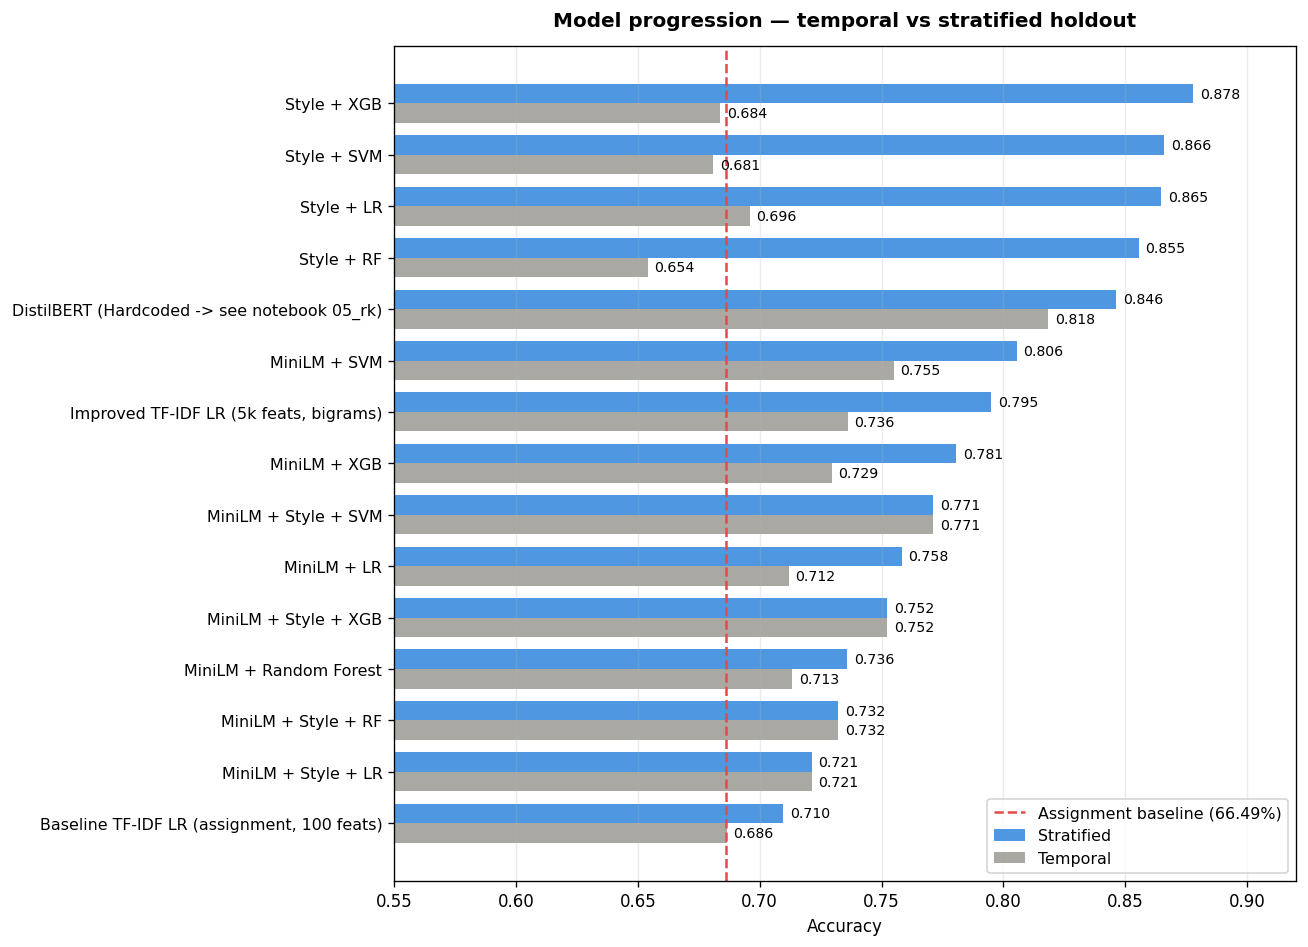

In [38]:
model_results = {
    'Baseline TF-IDF LR\n(assignment, 100 feats) - Temporal': acc_base,
    'Improved TF-IDF LR\n(5k feats, bigrams) - Temporal': acc_imp,
    'Baseline TF-IDF LR\n(assignment, 100 feats) - Stratified': acc_base_s,
    'Improved TF-IDF LR\n(5k feats, bigrams) - Stratified': acc_imp_s,
    'MiniLM + LR - Temporal': results_emb['MiniLM + LR - Temporal'],
    'MiniLM + Random Forest - Temporal': results_emb['MiniLM + RF - Temporal'],
    'MiniLM + SVM - Temporal': results_emb['MiniLM + SVM - Temporal'],
    'MiniLM + XGB - Temporal': results_emb['MiniLM + XGB - Temporal'],
    'Style + SVM - Temporal': results_style['Style + SVM - Temporal'],
    'Style + XGB - Temporal': results_style['Style + XGB - Temporal'],
    'Style + LR - Temporal': results_style['Style + LR - Temporal'],
    'Style + RF - Temporal': results_style['Style + RF - Temporal'],
    'MiniLM + Style + SVM - Temporal': results_fusion['MiniLM + Style + SVM - Temporal'],
    'MiniLM + Style + XGB - Temporal': results_fusion['MiniLM + Style + XGB - Temporal'],
    'MiniLM + Style + LR - Temporal': results_fusion['MiniLM + Style + LR - Temporal'],
    'MiniLM + Style + RF - Temporal': results_fusion['MiniLM + Style + RF - Temporal'],
    'MiniLM + LR - Stratified': results_emb_s['MiniLM + LR - Stratified'],
    'MiniLM + Random Forest - Stratified': results_emb_s['MiniLM + RF - Stratified'],
    'MiniLM + SVM - Stratified': results_emb_s['MiniLM + SVM - Stratified'],
    'MiniLM + XGB - Stratified': results_emb_s['MiniLM + XGB - Stratified'],
    'Style + SVM - Stratified': results_style_s['Style + SVM - Stratified'],
    'Style + XGB - Stratified': results_style_s['Style + XGB - Stratified'],
    'Style + LR - Stratified': results_style_s['Style + LR - Stratified'],
    'Style + RF - Stratified': results_style_s['Style + RF - Stratified'],
    'MiniLM + Style + SVM - Stratified': results_fusion_s['MiniLM + Style + SVM - Stratified'],
    'MiniLM + Style + XGB - Stratified': results_fusion_s['MiniLM + Style + XGB - Stratified'],
    'MiniLM + Style + LR - Stratified': results_fusion_s['MiniLM + Style + LR - Stratified'],
    'MiniLM + Style + RF - Stratified': results_fusion_s['MiniLM + Style + RF - Stratified'],
    'DistilBERT (Hardcoded -> see notebook 05_rk) - Stratified': 0.8463, # Hardcoded from notebook 05 for comparison purposes
    'DistilBERT (Hardcoded -> see notebook 05_rk) - Temporal': 0.8183, # Hardcoded from notebook 05 for comparison purposes
}

# ── Parse model_results into paired dicts ─────────────────────────────────────
temporal = {k.replace(' - Temporal', '').replace('\n', ' '): 
    v for k, v in model_results.items() if k.endswith('- Temporal')}
stratified = {k.replace(' - Stratified', '').replace('\n', ' '): 
    v for k, v in model_results.items() if k.endswith('- Stratified')}

# Sort by stratified accuracy descending
labels = sorted(stratified, key=stratified.get) # ascending for barh (bottom = highest)
strat_v = [stratified[l] for l in labels]
temp_v = [temporal[l]   for l in labels]

# ── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 8))

bars_s = ax.barh(x + width/2, strat_v, width, label='Stratified', color='#378ADD', alpha=0.88)
bars_t = ax.barh(x - width/2, temp_v,  width, label='Temporal',   color='#888780', alpha=0.72)

ax.axvline(0.686, color='#E24B4A', linestyle='--', linewidth=1.5, label='Assignment baseline (66.49%)')

ax.bar_label(bars_s, fmt='%.3f', padding=4, fontsize=8.5)
ax.bar_label(bars_t, fmt='%.3f', padding=4, fontsize=8.5)

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlim(0.55, 0.92)
ax.set_xlabel('Accuracy')
ax.set_title('Model progression — temporal vs stratified holdout', fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()

# os.makedirs('../figures', exist_ok = True)
plt.savefig('../figures/model_progression.png', dpi=150, bbox_inches='tight')

plt.show()

## 7 — Error Analysis

Because the HuggingFace benchmark is on future news headlines, it makes sense to chose our "best" model based on temporal test set accuracy. With that in mind, the MiniLM + Style + SMV model did best (SVM Classifier trained on concatenated MiniLM embeddings and style features). 

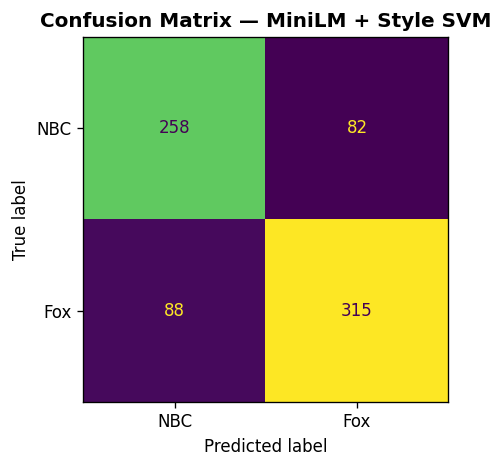


Errors: 170 / 743 (22.9%)

Sample misclassified headlines (Fox predicted as NBC):
                                                                                              title
                         Israel targets Hezbollah leader Nasrallah in strike on Beirut headquarters
           Zelenskyy downplays comment that Trump doesn't know how to end Russia's war with Ukraine
                Minnesota falls to No. 12 Michigan to go under .500 with Gov Tim Walz in attendance
Panthers owners donates $3 million to Hurricane Helene relief efforts; Bucs also give seven figures
                        Trump arrives at Alabama-Georgia game to chants of 'USA,' 'Four more years'

Sample misclassified headlines (NBC predicted as Fox):
                                                                                        title
     Kamala Harris' tough-on-migration pitch at the border points to a shifting national mood
Sarah McBride’s run to become the first openly trans member Congress is d

In [33]:
# Re-predict with best embedding model for error analysis
svm_best = SVC(kernel='rbf', C=1.0, random_state=42)
svm_best.fit(X_tr_fusion, y_tr_fusion)
y_pred_best = svm_best.predict(X_te_fusion)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_te_fusion, y_pred_best,
                                        display_labels=['NBC', 'Fox'],
                                        ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — MiniLM + Style SVM', fontweight='bold')
plt.tight_layout()

plt.savefig('../figures/best_svm_confusion_matrix.png', dpi = 150, bbox_inches = 'tight')
plt.show()

# Error examples
test_t_copy = test_t.copy()
test_t_copy['predicted'] = y_pred_best
test_t_copy['correct']   = (test_t_copy['predicted'] == test_t_copy['is_fox'])
errors = test_t_copy[~test_t_copy['correct']]

print(f'\nErrors: {len(errors)} / {len(test_t)} ({len(errors)/len(test_t):.1%})')
print('\nSample misclassified headlines (Fox predicted as NBC):')
print(errors[errors['is_fox']==1][['title']].head(5).to_string(index=False))
print('\nSample misclassified headlines (NBC predicted as Fox):')
print(errors[errors['is_fox']==0][['title']].head(5).to_string(index=False))